# Model Development

مقارنة مختصرة وواضحة بين نماذج شجرية مناسبة للمشروع:
- `decision_tree_balanced` على البيانات الأصلية مع `class_weight='balanced'`
- `decision_tree_smote` على بيانات تدريب متوازنة باستخدام `SMOTE`
- `random_forest_balanced` على البيانات الأصلية مع `class_weight='balanced'`
- `random_forest_smote` على بيانات تدريب متوازنة باستخدام `SMOTE`

التركيز هنا على وضوح المقارنة بين `Decision Tree` و`Random Forest` مع الاهتمام بمقاييس الفئة الإيجابية مثل `Recall` و `F1-score`.

In [127]:
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt


### 📦 الخلية 2: استيراد المكتبات الأساسية
استيراد جميع المكتبات المطلوبة للعمل مع البيانات والنماذج والرسوم

In [128]:
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DATA_PATH = BASE_DIR / "data" / "student_lifestyle_100k.csv"
PREPROCESSING_ARTIFACTS_PATH = BASE_DIR / "data" / "preprocessing_artifacts.pkl"

with open(BASE_DIR / "data" / "preprocessed_original.pkl", "rb") as f:
    X_train_original, X_val_scaled, X_test_scaled, y_train_original, y_val, y_test = pickle.load(f)

with open(BASE_DIR / "notebooks" / "preprocessed_smote.pkl", "rb") as f:
    X_train_smote, _, _, y_train_smote, _, _ = pickle.load(f)

with open(PREPROCESSING_ARTIFACTS_PATH, "rb") as f:
    preprocessing_artifacts = pickle.load(f)

preprocessor = preprocessing_artifacts["preprocessor"]
feature_names = list(preprocessing_artifacts["processed_feature_names"])

print("Number of processed features:", len(feature_names))
feature_names


FileNotFoundError: [Errno 2] No such file or directory: '/Users/khawlh/Desktop/un/ML/university students ml/notebooks/preprocessed_smote.pkl'

### 📂 الخلية 3: تحميل البيانات والميزات
تحميل:
- البيانات المعالجة الأصلية (Train/Val/Test)
- البيانات المعالجة بـ SMOTE
- قائمة أسماء الميزات من البيانات الخام

In [ ]:
train_distribution_df = pd.concat(
    {
        "original_count": pd.Series(y_train_original).value_counts().sort_index(),
        "original_ratio": pd.Series(y_train_original).value_counts(normalize=True).sort_index(),
        "smote_count": pd.Series(y_train_smote).value_counts().sort_index(),
        "smote_ratio": pd.Series(y_train_smote).value_counts(normalize=True).sort_index(),
    },
    axis=1,
)

train_distribution_df.index.name = "class"
train_distribution_df.round(4)


,original_count,original_ratio,smote_count,smote_ratio
class,,,,
0,71950,0.8994,71950,0.5
1,8050,0.1006,71950,0.5


### ⚖️ الخلية 4: مقارنة توزيع الفئات
جدول مقارن يعرض:
- العدد والنسبة للبيانات الأصلية
- العدد والنسبة بعد SMOTE
- يوضح كيف ساعد SMOTE في توازن البيانات

In [ ]:
from sklearn.linear_model import LogisticRegression


def evaluate_predictions(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_class_0": report["0"]["precision"],
        "recall_class_0": report["0"]["recall"],
        "f1_class_0": report["0"]["f1-score"],
        "precision_class_1": report["1"]["precision"],
        "recall_class_1": report["1"]["recall"],
        "f1_class_1": report["1"]["f1-score"],
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"],
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "report": report,
        "confusion_matrix": [[int(tn), int(fp)], [int(fn), int(tp)]],
    }


def run_experiment(name, model, X_train_used, y_train_used):
    model.fit(X_train_used, y_train_used)

    y_val_pred = model.predict(X_val_scaled)
    y_test_pred = model.predict(X_test_scaled)

    val_metrics = evaluate_predictions(y_val, y_val_pred)
    test_metrics = evaluate_predictions(y_test, y_test_pred)

    return {
        "experiment": name,
        "model_type": type(model).__name__,
        "train_samples": int(len(y_train_used)),
        "train_positive_ratio": float(pd.Series(y_train_used).mean()),
        "val_accuracy": val_metrics["accuracy"],
        "val_precision_class_1": val_metrics["precision_class_1"],
        "val_recall_class_1": val_metrics["recall_class_1"],
        "val_f1_class_1": val_metrics["f1_class_1"],
        "test_accuracy": test_metrics["accuracy"],
        "test_precision_class_0": test_metrics["precision_class_0"],
        "test_recall_class_0": test_metrics["recall_class_0"],
        "test_f1_class_0": test_metrics["f1_class_0"],
        "test_precision_class_1": test_metrics["precision_class_1"],
        "test_recall_class_1": test_metrics["recall_class_1"],
        "test_f1_class_1": test_metrics["f1_class_1"],
        "test_macro_f1": test_metrics["macro_f1"],
        "test_weighted_f1": test_metrics["weighted_f1"],
        "tn": test_metrics["tn"],
        "fp": test_metrics["fp"],
        "fn": test_metrics["fn"],
        "tp": test_metrics["tp"],
        "val_report": val_metrics["report"],
        "test_report": test_metrics["report"],
        "test_confusion_matrix": test_metrics["confusion_matrix"],
        "model": model,
    }


experiments = {
    "logistic_smote": (
        LogisticRegression(
            random_state=42,
            max_iter=1000
        ),
        X_train_smote,
        y_train_smote,
    ),
    "logistic_balanced": (
        LogisticRegression(
            random_state=42,
            max_iter=1000,
            class_weight="balanced"
        ),
        X_train_original,
        y_train_original,
   ),
    "decision_tree_balanced": (
        DecisionTreeClassifier(
            random_state=42,
            max_depth=8,
            min_samples_leaf=20,
            class_weight="balanced",
        ),
        X_train_original,
        y_train_original,
    ),
    "decision_tree_smote": (
        DecisionTreeClassifier(
            random_state=42,
            max_depth=8,
            min_samples_leaf=20,
        ),
        X_train_smote,
        y_train_smote,
    ),
    "random_forest_balanced": (
        RandomForestClassifier(
            n_estimators=250,
            random_state=42,
            max_depth=12,
            min_samples_leaf=5,
            class_weight="balanced",
            n_jobs=-1,
        ),
        X_train_original,
        y_train_original,
    ),
    "random_forest_smote": (
        RandomForestClassifier(
            n_estimators=250,
            random_state=42,
            max_depth=12,
            min_samples_leaf=5,
            n_jobs=-1,
        ),
        X_train_smote,
        y_train_smote,
    ),
}

trained_models = {}
results = []

for name, (model, X_train_used, y_train_used) in experiments.items():
    result = run_experiment(name, model, X_train_used, y_train_used)
    trained_models[name] = result.pop("model")
    results.append(result)

results_df = (
    pd.DataFrame(results)
    .sort_values(by=["test_f1_class_1", "test_recall_class_1"], ascending=False)
    .reset_index(drop=True)
)

results_df[["experiment", "model_type", "test_accuracy", "test_recall_class_1", "test_f1_class_1"]].round(4)


,experiment,model_type,test_accuracy,test_recall_class_1,test_f1_class_1
0,random_forest_balanced,RandomForestClassifier,0.7382,0.5835,0.3096
1,decision_tree_balanced,DecisionTreeClassifier,0.7291,0.6014,0.3088
2,random_forest_smote,RandomForestClassifier,0.7553,0.5149,0.2974
3,decision_tree_smote,DecisionTreeClassifier,0.7529,0.5199,0.2974
4,logistic_smote,LogisticRegression,0.6176,0.6431,0.2528
5,logistic_balanced,LogisticRegression,0.6160,0.6441,0.2523


### 🧪 الخلية 5: تعريف الدوال وتشغيل التجارب
**الدوال:**
- `evaluate_predictions()`: حساب مقاييس الأداء (Accuracy, Precision, Recall, F1)
- `run_experiment()`: تدريب واختبار نموذج واحد

**التجارب (6 نماذج):**
| النموذج | البيانات | الطريقة |
|---------|---------|--------|
| Logistic Regression | SMOTE | غير متوازن |
| Logistic Regression | أصلية | Balanced |
| Decision Tree | أصلية | Balanced |
| Decision Tree | SMOTE | غير متوازن |
| Random Forest | أصلية | Balanced |
| Random Forest | SMOTE | غير متوازن |

**النتيجة:** جدول مرتب حسب F1-score

## Summary Comparison

هذا الجدول هو المرجع السريع لاتخاذ القرار، مع التركيز على `test_f1_class_1` و `test_recall_class_1`.

In [ ]:
summary_columns = [
    "experiment",
    "model_type",
    "train_positive_ratio",
    "test_accuracy",
    "test_precision_class_1",
    "test_recall_class_1",
    "test_f1_class_1",
    "test_macro_f1",
    "test_weighted_f1",
]

summary_df = (
    results_df[summary_columns]
    .sort_values(by=["test_f1_class_1", "test_recall_class_1"], ascending=False)
    .reset_index(drop=True)
    .round(4)
)

summary_df


,experiment,model_type,train_positive_ratio,test_accuracy,test_precision_class_1,test_recall_class_1,test_f1_class_1,test_macro_f1,test_weighted_f1
0,random_forest_balanced,RandomForestClassifier,0.1006,0.7382,0.2107,0.5835,0.3096,0.5740,0.7853
1,decision_tree_balanced,DecisionTreeClassifier,0.1006,0.7291,0.2077,0.6014,0.3088,0.5701,0.7789
2,random_forest_smote,RandomForestClassifier,0.5000,0.7553,0.2091,0.5149,0.2974,0.5746,0.7961
3,decision_tree_smote,DecisionTreeClassifier,0.5000,0.7529,0.2083,0.5199,0.2974,0.5738,0.7945
4,logistic_smote,LogisticRegression,0.5000,0.6176,0.1573,0.6431,0.2528,0.4979,0.6937
5,logistic_balanced,LogisticRegression,0.1006,0.6160,0.1569,0.6441,0.2523,0.4970,0.6924


### 📊 الخلية 7: جدول الملخص السريع
عرض أهم المقاييس:
- معلومات النموذج والتدريب
- Accuracy على بيانات الاختبار
- Precision, Recall, F1 للفئة الموجبة
- Macro و Weighted F1

مرتب حسب الأداء الأفضل

## Detailed Comparison

هذا الجدول يبقي التفاصيل المهمة كلها في مكان واحد بدل تكرار تقارير طويلة لكل تجربة.

In [ ]:
detailed_columns = [
    "experiment",
    "model_type",
    "train_samples",
    "train_positive_ratio",
    "val_accuracy",
    "val_precision_class_1",
    "val_recall_class_1",
    "val_f1_class_1",
    "test_accuracy",
    "test_precision_class_0",
    "test_recall_class_0",
    "test_f1_class_0",
    "test_precision_class_1",
    "test_recall_class_1",
    "test_f1_class_1",
    "test_macro_f1",
    "test_weighted_f1",
    "tn",
    "fp",
    "fn",
    "tp",
]

detailed_df = (
    results_df[detailed_columns]
    .sort_values(by=["test_f1_class_1", "test_recall_class_1"], ascending=False)
    .reset_index(drop=True)
    .round(4)
)

detailed_df


,experiment,model_type,train_samples,train_positive_ratio,val_accuracy,val_precision_class_1,val_recall_class_1,val_f1_class_1,test_accuracy,test_precision_class_0,...,test_f1_class_0,test_precision_class_1,test_recall_class_1,test_f1_class_1,test_macro_f1,test_weighted_f1,tn,fp,fn,tp
0,random_forest_balanced,RandomForestClassifier,80000,0.1006,0.7431,0.2226,0.6233,0.3280,0.7382,0.9419,...,0.8385,0.2107,0.5835,0.3096,0.5740,0.7853,6795,2199,419,587
1,decision_tree_balanced,DecisionTreeClassifier,80000,0.1006,0.7345,0.2208,0.6481,0.3294,0.7291,0.9434,...,0.8315,0.2077,0.6014,0.3088,0.5701,0.7789,6686,2308,401,605
2,random_forest_smote,RandomForestClassifier,143900,0.5000,0.7599,0.2222,0.5547,0.3173,0.7553,0.9351,...,0.8518,0.2091,0.5149,0.2974,0.5746,0.7961,7035,1959,488,518
3,decision_tree_smote,DecisionTreeClassifier,143900,0.5000,0.7584,0.2220,0.5596,0.3179,0.7529,0.9355,...,0.8501,0.2083,0.5199,0.2974,0.5738,0.7945,7006,1988,483,523
4,logistic_smote,LogisticRegression,143900,0.5000,0.6220,0.1669,0.6909,0.2689,0.6176,0.9390,...,0.7430,0.1573,0.6431,0.2528,0.4979,0.6937,5529,3465,359,647
5,logistic_balanced,LogisticRegression,80000,0.1006,0.6208,0.1666,0.6918,0.2685,0.6160,0.9390,...,0.7417,0.1569,0.6441,0.2523,0.4970,0.6924,5512,3482,358,648


### 🔍 الخلية 9: جدول التفاصيل الكاملة
جدول شامل يتضمن:
- معلومات التدريب والتحقق
- جميع مقاييس الاختبار (Precision, Recall, F1 لكل فئة)
- عناصر مصفوفة الالتباس (TP, TN, FP, FN)
- جميع النماذج مقارنة في جدول واحد

## Focused Best-Model Report

بدل عرض تقرير كامل لكل تجربة، نعرض هنا التقرير التفصيلي للنموذج الأفضل حسب `test_f1_class_1`.

In [ ]:
focus_model_name = summary_df.iloc[0]["experiment"]
focus_row = results_df.loc[results_df["experiment"] == focus_model_name].iloc[0]

focus_test_report_df = (
    pd.DataFrame(focus_row["test_report"])
    .T
    .loc[["0", "1", "accuracy", "macro avg", "weighted avg"]]
    .round(4)
)

focus_confusion_df = pd.DataFrame(
    focus_row["test_confusion_matrix"],
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"],
)

display(pd.DataFrame([focus_row[["experiment", "model_type", "test_accuracy", "test_recall_class_1", "test_f1_class_1"]]]).round(4))
display(focus_test_report_df)
focus_confusion_df


,experiment,model_type,test_accuracy,test_recall_class_1,test_f1_class_1
0,random_forest_balanced,RandomForestClassifier,0.7382,0.5835,0.3096


,precision,recall,f1-score,support
0,0.9419,0.7555,0.8385,8994.0000
1,0.2107,0.5835,0.3096,1006.0000
accuracy,0.7382,0.7382,0.7382,0.7382
macro avg,0.5763,0.6695,0.5740,10000.0000
weighted avg,0.8684,0.7382,0.7853,10000.0000


,Predicted 0,Predicted 1
Actual 0,6795,2199
Actual 1,419,587


### 🏆 الخلية 11: تقرير النموذج الأفضل المفصل
عرض معلومات شاملة للنموذج الأفضل فقط:
- اسم التجربة ونوع النموذج ومقاييس الأداء الرئيسية
- تقرير التصنيف التفصيلي (Precision, Recall, F1 لكل فئة)
- مصفوفة الالتباس (كم صح/خطأ في التنبؤات)

## Feature Importance

هذه الخلية تساعد في تفسير النتائج، وهي نقطة مهمة في التقرير والعرض النهائي.

In [ ]:
best_model_name = summary_df.iloc[0]["experiment"]
best_model = trained_models[best_model_name]

if hasattr(best_model, "feature_importances_"):
    importance_values = best_model.feature_importances_
elif hasattr(best_model, "coef_"):
    importance_values = np.abs(best_model.coef_).ravel()
else:
    raise ValueError(f"Model {type(best_model).__name__} does not expose feature importances or coefficients.")

if len(importance_values) != len(feature_names):
    raise ValueError(
        f"Feature importance length ({len(importance_values)}) does not match "
        f"processed feature names length ({len(feature_names)})."
    )

feature_importance_df = (
    pd.DataFrame(
        {
            "feature": feature_names,
            "importance": importance_values,
        }
    )
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance_df


,feature,importance
0,num__CGPA,0.511330
1,num__Stress_Level,0.102692
2,num__Sleep_Duration,0.101915
3,num__Physical_Activity,0.072821
4,num__Study_Hours,0.071869
5,num__Social_Media_Hours,0.068415
6,num__Age,0.030326
7,cat__Gender_Male,0.006368
8,cat__Gender_Female,0.006077
9,cat__Department_Business,0.005911


### ⭐ الخلية 13: أهمية الميزات
استخراج قيم أهمية كل ميزة من النموذج الأفضل:
- جدول يحتوي على اسم الميزة ودرجة الأهمية (0-1)
- مرتب تنازليًا (الميزات الأهم أولاً)
- يساعد في فهم أي العوامل لها التأثير الأكبر على التنبؤ

## Saved Models

يتم حفظ النموذج الأفضل إجمالًا، مع حفظ أفضل `Decision Tree` وأفضل `Random Forest` بشكل منفصل، بالإضافة إلى ملفات CSV وJSON المساعدة.

In [ ]:
from pathlib import Path

results_dir = BASE_DIR / "results"
models_dir = BASE_DIR / "models"
results_dir.mkdir(exist_ok=True)
models_dir.mkdir(exist_ok=True)

summary_df.to_csv(results_dir / "tree_model_comparison.csv", index=False)
feature_importance_df.to_csv(results_dir / "best_tree_feature_importance.csv", index=False)

decision_tree_best_name = (
    results_df[results_df["model_type"] == "DecisionTreeClassifier"].iloc[0]["experiment"]
)
random_forest_best_name = (
    results_df[results_df["model_type"] == "RandomForestClassifier"].iloc[0]["experiment"]
)

def make_prediction_pipeline(model):
    return Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", model),
        ]
    )

best_pipeline = make_prediction_pipeline(trained_models[best_model_name])
decision_tree_pipeline = make_prediction_pipeline(trained_models[decision_tree_best_name])
random_forest_pipeline = make_prediction_pipeline(trained_models[random_forest_best_name])

with open(models_dir / "saved_tree_best_model.pkl", "wb") as f:
    pickle.dump(trained_models[best_model_name], f)

with open(models_dir / "saved_decision_tree.pkl", "wb") as f:
    pickle.dump(trained_models[decision_tree_best_name], f)

with open(models_dir / "saved_random_forest.pkl", "wb") as f:
    pickle.dump(trained_models[random_forest_best_name], f)

with open(models_dir / "saved_best_model_pipeline.pkl", "wb") as f:
    pickle.dump(best_pipeline, f)

with open(models_dir / "saved_decision_tree_pipeline.pkl", "wb") as f:
    pickle.dump(decision_tree_pipeline, f)

with open(models_dir / "saved_random_forest_pipeline.pkl", "wb") as f:
    pickle.dump(random_forest_pipeline, f)

details_payload = {
    "best_experiment": best_model_name,
    "decision_tree_best_experiment": decision_tree_best_name,
    "random_forest_best_experiment": random_forest_best_name,
    "processed_feature_names": feature_names,
    "preprocessing_artifacts_file": "../data/preprocessing_artifacts.pkl",
    "saved_pipeline_files": [
        "../models/saved_best_model_pipeline.pkl",
        "../models/saved_decision_tree_pipeline.pkl",
        "../models/saved_random_forest_pipeline.pkl",
    ],
    "results": results,
}

with open(results_dir / "tree_model_details.json", "w", encoding="utf-8") as f:
    json.dump(details_payload, f, ensure_ascii=False, indent=2)

{
    "best_experiment": best_model_name,
    "decision_tree_best_experiment": decision_tree_best_name,
    "random_forest_best_experiment": random_forest_best_name,
    "saved_files": [
        "../models/saved_tree_best_model.pkl",
        "../models/saved_decision_tree.pkl",
        "../models/saved_random_forest.pkl",
        "../models/saved_best_model_pipeline.pkl",
        "../models/saved_decision_tree_pipeline.pkl",
        "../models/saved_random_forest_pipeline.pkl",
        "../results/tree_model_comparison.csv",
        "../results/best_tree_feature_importance.csv",
        "../results/tree_model_details.json",
    ],
}


{'best_experiment': 'random_forest_balanced',
 'decision_tree_best_experiment': 'decision_tree_balanced',
 'random_forest_best_experiment': 'random_forest_balanced',
 'saved_files': ['../models/saved_tree_best_model.pkl',
  '../models/saved_decision_tree.pkl',
  '../models/saved_random_forest.pkl',
  '../models/saved_best_model_pipeline.pkl',
  '../models/saved_decision_tree_pipeline.pkl',
  '../models/saved_random_forest_pipeline.pkl',
  '../results/tree_model_comparison.csv',
  '../results/best_tree_feature_importance.csv',
  '../results/tree_model_details.json']}

### 💾 الخلية 15: حفظ النماذج والملفات
حفظ المخرجات:
- **النماذج** (3 ملفات pickle):
  - أفضل نموذج عام
  - أفضل Decision Tree
  - أفضل Random Forest

- **النتائج** (3 ملفات):
  - `tree_model_comparison.csv`: جدول الملخص
  - `best_tree_feature_importance.csv`: أهمية الميزات
  - `tree_model_details.json`: بيانات كاملة

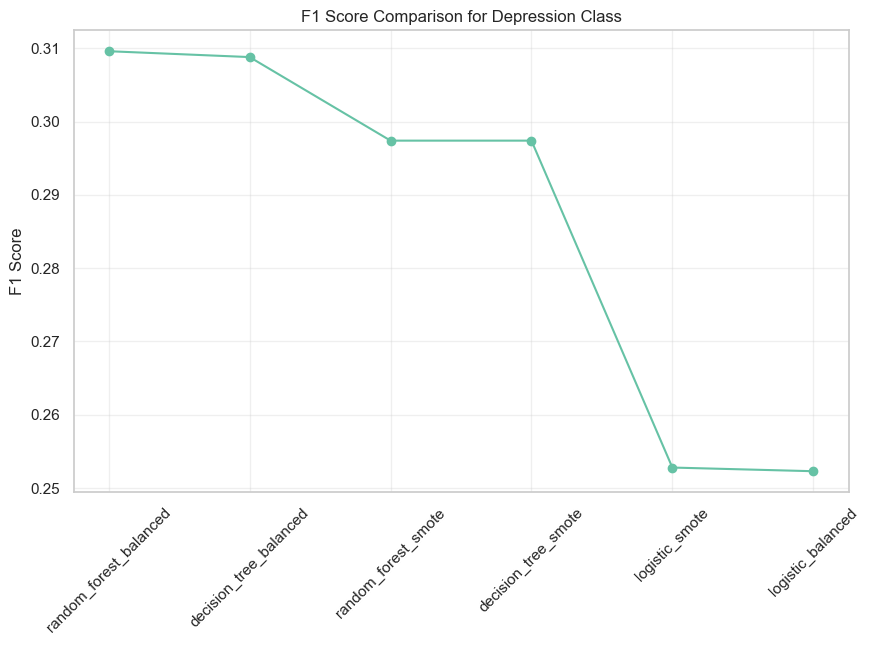

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(
    summary_df["experiment"],
    summary_df["test_f1_class_1"],
    marker='o'
)

plt.title("F1 Score Comparison for Depression Class")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.show()

### 📈 الخلايا 16-18: رسوم بيانية مقارنة
- **الخلية 16**: رسم F1-score لجميع النماذج
- **الخلية 17**: رسم Recall لجميع النماذج (مهم جداً لكشف الاكتئاب)
- **الخلية 18**: مقارنة ثلاث مقاييس معاً (Precision, Recall, F1)

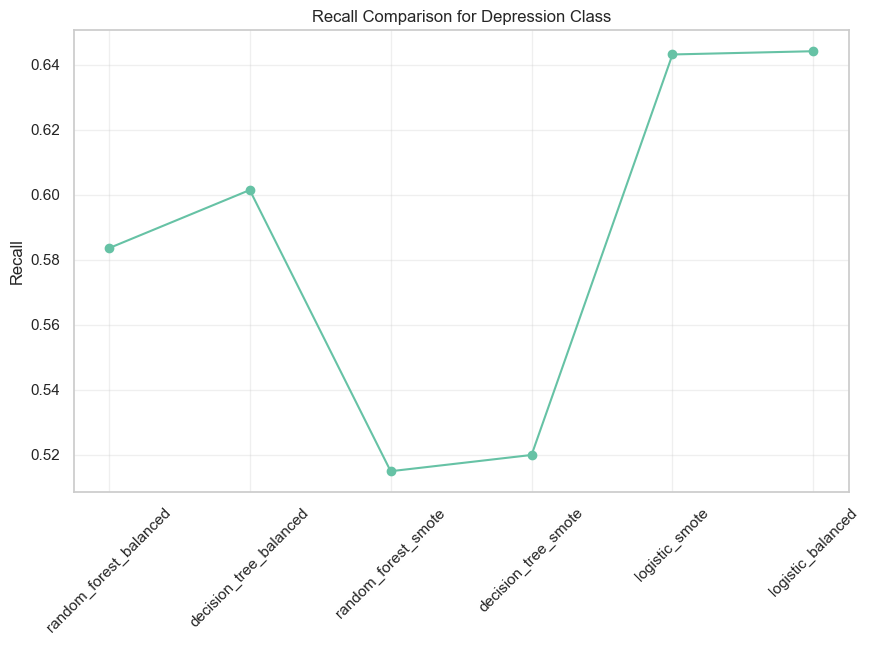

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(
    summary_df["experiment"],
    summary_df["test_recall_class_1"],
    marker='o'
)

plt.title("Recall Comparison for Depression Class")
plt.ylabel("Recall")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.show()

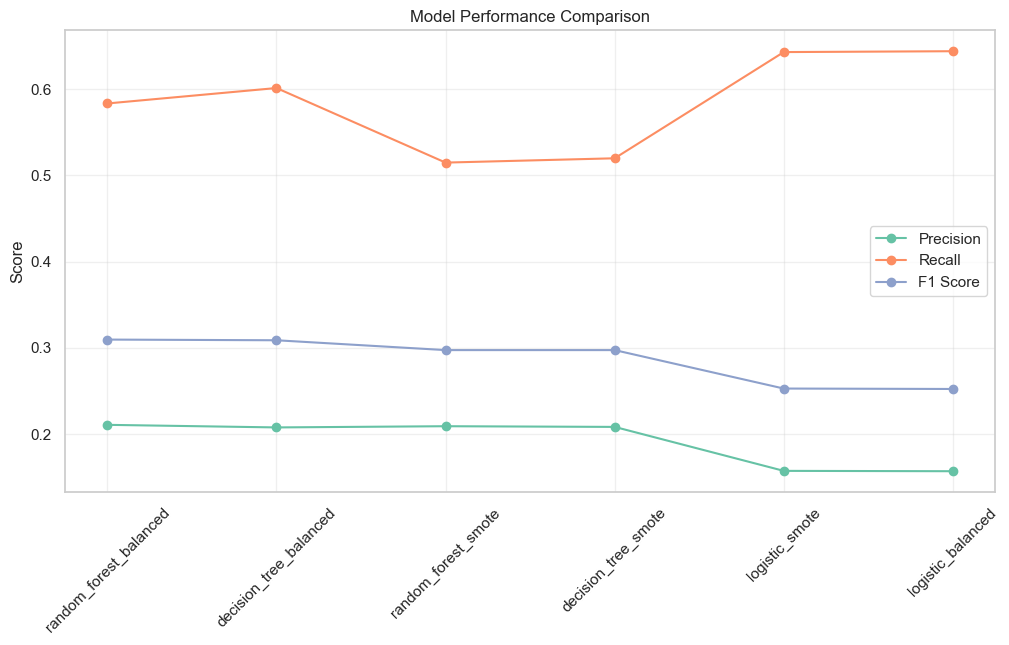

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(summary_df["experiment"], summary_df["test_precision_class_1"], marker='o', label='Precision')
plt.plot(summary_df["experiment"], summary_df["test_recall_class_1"], marker='o', label='Recall')
plt.plot(summary_df["experiment"], summary_df["test_f1_class_1"], marker='o', label='F1 Score')

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()